In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

## Goal
##### The goal of this lab is to measure the relationship between the radiation count registered in the Geiger Pro relative to the distance from the cesium block that emits the radiation.


## Procedure for the Lab

1. Measure the average background radiation.
2. Measure the radiation from the cesium source at increasing distances.
3. Fit a curve to the radiation vs. distance data using the inverse square law model.
4. Visualize the plotted data.
5. Linearize the data by taking the natural logarithm of the relationship:  
   $$ \text{Radiation} = A \cdot d^{-2} $$
6. Plot the linear fit model.


In [3]:
# Measured background radiation.

background_data = pd.read_excel("data/background.xlsx")
background_data

,Time (s),Radiation (Counts)
0,30,3
1,60,7
2,90,10
3,120,5
4,150,6
5,180,8
6,210,7
7,240,8
8,270,8
9,300,3


In [4]:
# getting the average background radiaton
average_background_radiation = np.mean((background_data["Radiation (Counts)"]))

# getting teh uncerainty for the backgound radiation
background_radiation_uncertainty = np.std(background_data["Radiation (Counts)"])

average_background_radiation, background_radiation_uncertainty

(np.float64(6.5), np.float64(2.1563858652847827))

$$
\text{Average background radiation} = 7 \pm 2 \space Counts
$$



### The radiation emitted by the cesium source is measured at different distance intervals. The initial distance is 0.5 cm from the Geiger Pro, and then we gradually increased the distance.

In [5]:
radiation_data = pd.read_csv("data/caesium(in).csv")
radiation_data["Corrected Radiation (counts/int)"] = np.nan
radiation_data

,Distance (m),Radiation (Counts),Corrected Radiation (counts/int)
0,0.005,69994,NaN
1,0.015,24211,NaN
2,0.030,6087,NaN
3,0.050,2304,NaN
4,0.080,799,NaN
5,0.120,350,NaN
6,0.170,174,NaN
7,0.230,102,NaN
8,0.300,50,NaN
9,0.380,33,NaN


$$
\text{Distance Uncertainity} = 0.5 \space cm
$$

#### We then subtract the background radiation from each radiation measurement to isolate the radiation emitted by the cesium


In [6]:
distance_uncertainity = 0.005

# populationg the Corrected Radiation by excluding the average background radiation
radiation_data["Corrected Radiation (counts/int)"] = radiation_data["Radiation (Counts)"] - average_background_radiation

# getting the uncertainity for each radiation count
radiation_data["Radiation Count Uncertainity (counts)"] = np.sqrt(radiation_data["Radiation (Counts)"])

# Rounding the Radiation Count to the nearest integer becasuse counts are discrete
radiation_data["Corrected Radiation (counts/int)"] = radiation_data["Corrected Radiation (counts/int)"].apply(lambda x: np.round(x))
radiation_data["Radiation Count Uncertainity (counts)"] = radiation_data["Radiation Count Uncertainity (counts)"].apply(lambda x: np.round(x))
radiation_data

,Distance (m),Radiation (Counts),Corrected Radiation (counts/int),Radiation Count Uncertainity (counts)
0,0.005,69994,69988.0,265.0
1,0.015,24211,24204.0,156.0
2,0.030,6087,6080.0,78.0
3,0.050,2304,2298.0,48.0
4,0.080,799,792.0,28.0
5,0.120,350,344.0,19.0
6,0.170,174,168.0,13.0
7,0.230,102,96.0,10.0
8,0.300,50,44.0,7.0
9,0.380,33,26.0,6.0


## Dominant source of uncertainity 

#### The dominant source of uncertainty arises from the randomness of radiation counts, which follow a Poisson distribution. To obtain more accurate data, we would need to allow the Geiger counter to run for a longer duration, but each radiation measurement is limited to 30 seconds.

## Scattering the data points before fitting a best fit line

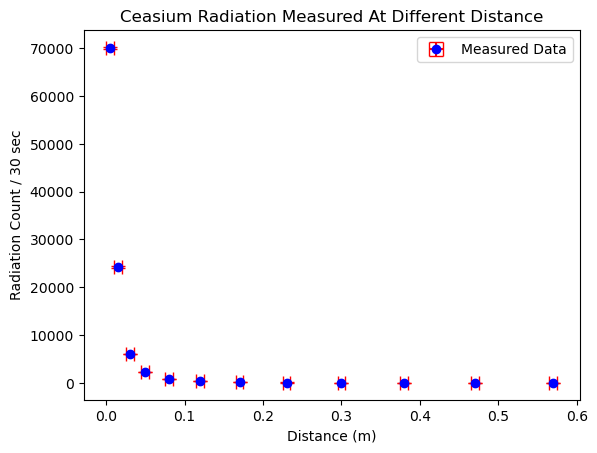

In [7]:
x = radiation_data["Distance (m)"]
y = radiation_data["Corrected Radiation (counts/int)"]
y_err = radiation_data["Radiation Count Uncertainity (counts)"]

plt.errorbar(x, y, yerr=y_err, xerr=distance_uncertainity, fmt="o", capsize=5,  markersize=6, color="blue", ecolor="red", label="Measured Data")
plt.xlabel(r"Distance (m)")
plt.ylabel("Radiation Count / 30 sec")
plt.title("Ceasium radiation measured at different distance".title())
plt.legend(); pass


### Relation Used for Fitting a Curve

$$
\text{Radiation} = A \cdot \text{distance}^{-2}
$$

In [8]:
# The relation between the distance and radiation
# follows inverse square law
quadratic_model = lambda x, A: A * (x**(-2))


x = radiation_data["Distance (m)"];
y = radiation_data["Corrected Radiation (counts/int)"]
error = radiation_data["Radiation Count Uncertainity (counts)"]


parameter, errors = curve_fit( quadratic_model, x, y,  sigma=error,  absolute_sigma=True )
parameter

array([1.92625592])

$$
\text{Estimaged A Value} = 2
$$

### Fitting the Curve along side the data points

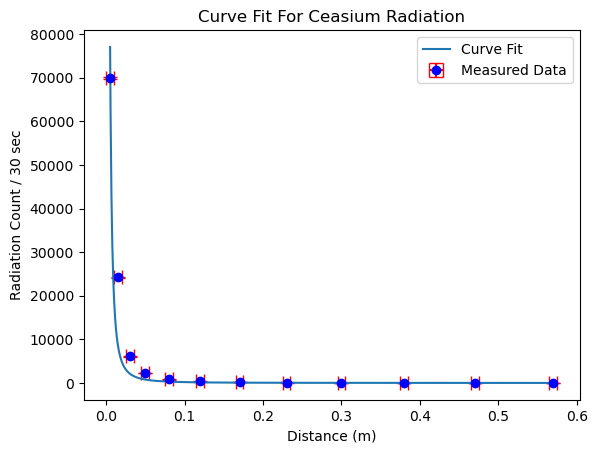

In [9]:
x = radiation_data["Distance (m)"]
y = radiation_data["Corrected Radiation (counts/int)"]
y_err = radiation_data["Radiation Count Uncertainity (counts)"]

plt.errorbar(x, y, yerr=y_err, xerr=distance_uncertainity, fmt="o", capsize=5,  markersize=6, color="blue", ecolor="red", label="Measured Data")
plt.xlabel(r"Distance (m)")
plt.ylabel("Radiation Count / 30 sec")
plt.title("Curve fit for ceasium radiation".title())

x = np.linspace(min(x), max(x), 1000)
y = quadratic_model(x, parameter[0])
plt.plot(x, y, label="Curve Fit")
plt.legend(); pass

### Now, we are going to linearize the relationship to better understand the connection between radiation and distance.

#### To do this we are going to take the natural logarithm of the relation $$\text{Radiation} = A \cdot \text{distance}^{-2}$$

$$
\text{Radiation} = A \cdot \text{distance}^{-2}
$$


$$
\ln(\text{Radiation}) = \ln A + \ln \left( \text{distance}^{-2} \right)
$$



$$
\ln(\text{Radiation}) = \ln A - 2 \ln (\text{distance})
$$

## Error propagation for the natural log

$$
\delta X = \sqrt{ \left( \frac{\partial X}{\partial d} \delta d \right)^2 }
$$

$$
\frac{\partial X}{\partial d} = \frac{1}{d}
$$

$$
\delta X = \sqrt{ \left( \frac{\delta d}{d} \right)^2 }
$$


In [10]:
# Taking the natural log of the radiation and distance
radiation_data["Natural Log of Radiation"] = np.log(radiation_data["Corrected Radiation (counts/int)"])
radiation_data["Natural log of distance".title()] = np.log(radiation_data["Distance (m)"])

# Taking the natural log of the estimated A parameter
ln_A = np.log(parameter[0])


In [11]:
# uncertainity function according to the error propagation
uncertainity = lambda x, x_error: np.sqrt( (N_error / N)**2 )

# Getting the propagated uncertainity of the natural log of radiation
N = radiation_data["Corrected Radiation (counts/int)"]
N_error = radiation_data["Radiation Count Uncertainity (counts)"]
radiation_data["natural log radiation uncertainty".title()] = uncertainity(N, N_error)

# Getting the propagated uncertainity of the natural log of distance
d = radiation_data["Distance (m)"]
d_error = distance_uncertainity
radiation_data["natural log distance uncertainity".title()] = uncertainity(N, N_error)

radiation_data

,Distance (m),Radiation (Counts),Corrected Radiation (counts/int),Radiation Count Uncertainity (counts),Natural Log of Radiation,Natural Log Of Distance,Natural Log Radiation Uncertainty,Natural Log Distance Uncertainity
0,0.005,69994,69988.0,265.0,11.156079,-5.298317,0.003786,0.003786
1,0.015,24211,24204.0,156.0,10.094273,-4.199705,0.006445,0.006445
2,0.030,6087,6080.0,78.0,8.712760,-3.506558,0.012829,0.012829
3,0.050,2304,2298.0,48.0,7.739794,-2.995732,0.020888,0.020888
4,0.080,799,792.0,28.0,6.674561,-2.525729,0.035354,0.035354
5,0.120,350,344.0,19.0,5.840642,-2.120264,0.055233,0.055233
6,0.170,174,168.0,13.0,5.123964,-1.771957,0.077381,0.077381
7,0.230,102,96.0,10.0,4.564348,-1.469676,0.104167,0.104167
8,0.300,50,44.0,7.0,3.784190,-1.203973,0.159091,0.159091
9,0.380,33,26.0,6.0,3.258097,-0.967584,0.230769,0.230769


### Fitting the linear model of the natural logs

In [12]:
linear_model = lambda x, A, B: A * x + B

# getting the x and y values and their erorrs
x = radiation_data["Natural Log Of Distance"];
y = radiation_data["Natural Log of Radiation"]

parameter, errors = curve_fit( linear_model, x, y,   absolute_sigma=True )

# getting the slopes, intercepts and errors
slope = parameter[0]; 
intercept = parameter[1]
d_slope = errors[0][0]
d_intercept = errors[1][1]

slope, intercept, d_slope, d_intercept

(np.float64(-1.931291699375162),
 np.float64(1.6338222857289917),
 np.float64(0.04171920802651306),
 np.float64(0.3004702800437203))

#### The slope and intercept errors are so small that we can consider them negligible

$$
\text{Estimated slope} = -1.90 \pm 0.04
$$

$$
\text{Estimated intercept} = 4.0 \pm 0.3
$$


## Plotting the linearized curve fit for the natural logarithm of the radiation and distance

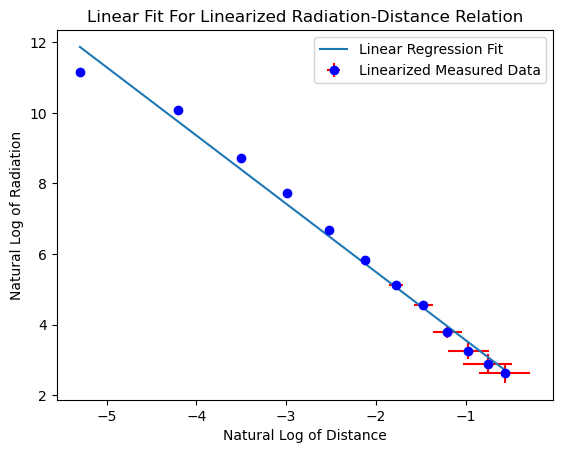

In [13]:
fit_model = lambda x: (slope  * x) + intercept

# getting the x, y and the errors
x = radiation_data["Natural Log Of Distance"]
y = radiation_data["Natural Log of Radiation"]
x_error = radiation_data["Natural Log Distance Uncertainity"]
y_error = radiation_data["Natural Log Radiation Uncertainty"]

# plotting the error bar
plt.errorbar(x, y, yerr=y_error, xerr=x_error, fmt="o", color="blue", ecolor="red", label="Linearized Measured Data")
plt.xlabel("Natural Log of Distance")
plt.ylabel("Natural Log of Radiation")
plt.title("Linear fit for Linearized radiation-distance relation".title())

# plotting the regression fit
x = np.linspace(min(x), max(x), 1000)
y = fit_model(x)
plt.plot(x, y, label="Linear Regression Fit")

plt.legend(); pass

## Comparision to the accepted value:

#### The result compares reasonably well with the accepted value. Using the inverse square law, we estimated that the slope of the fit should be -2. The slope estimate we obtained is -1.9 ± 0.04, while the accepted value is -2. Although our result does not exactly match the accepted value, it is very close.


## Connection to physics

#### In this experiment, our observations align well with expectations from an electric field. We confirmed that radiation intensity decreases according to the inverse square law of distance. Furthermore, when we linearized the relationship using logarithms, the slope of the best-fit line was close to -2, reinforcing the theoretical prediction.



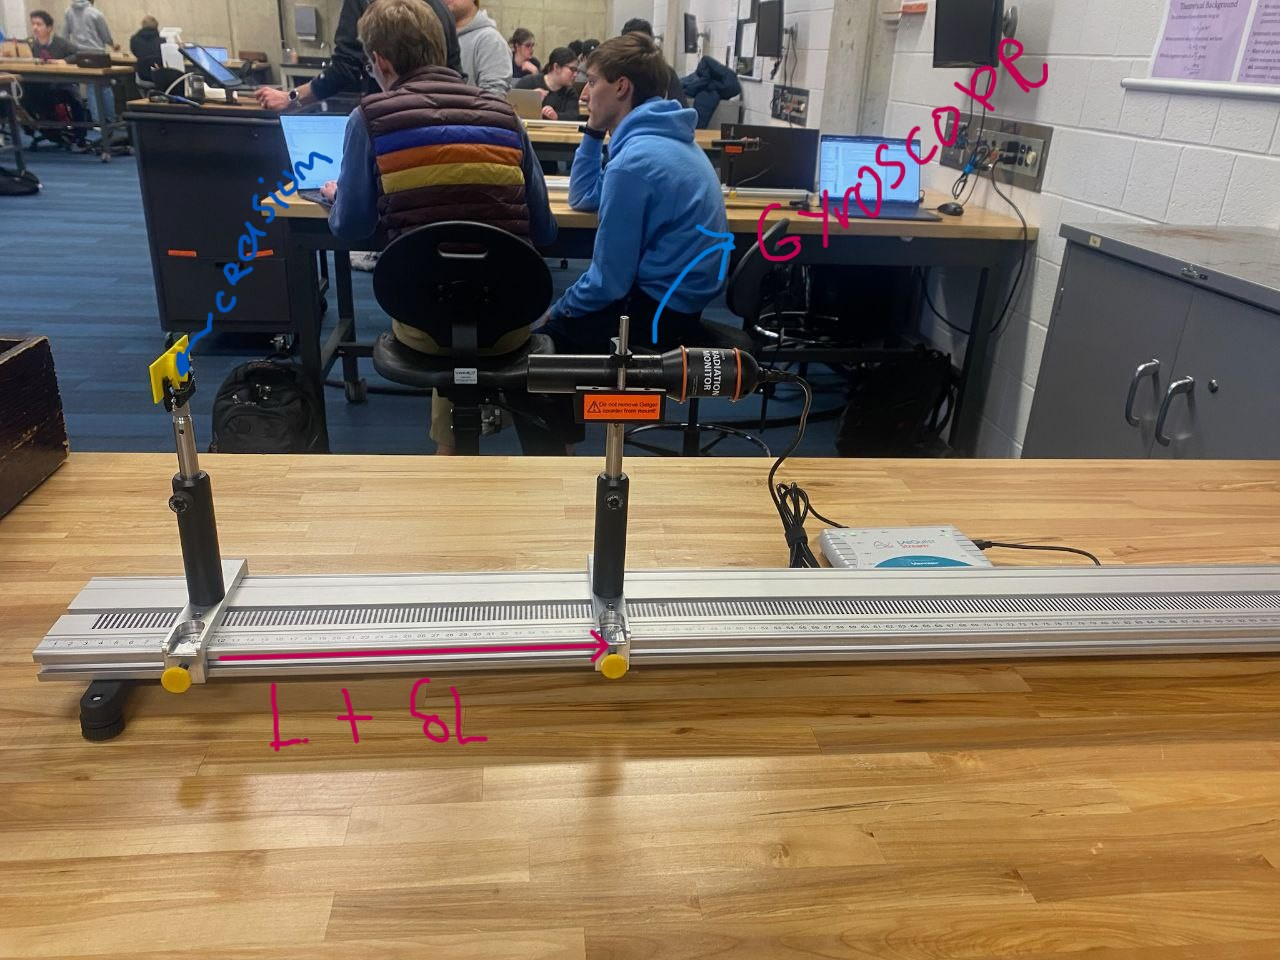